In [1]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [5]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
from datetime import timedelta
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
import pickle

In [3]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_offres_dates_creation = """ 
SELECT 
    off_date_creation
FROM 
    t_offre
WHERE
    off_date_creation >= DATEADD(YEAR, -4, GETDATE())
"""

offres_dates_creation = pd.read_sql_query(requete_offres_dates_creation, conn)

conn.commit()
cursor.close()
conn.close()

C:\Users\quent\AppData\Local\Temp\ipykernel_13564\3714901168.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  offres_dates_creation = pd.read_sql_query(requete_offres_dates_creation, conn)


✅ Taux de création estimé (λ) : 134.990901 offres par jour


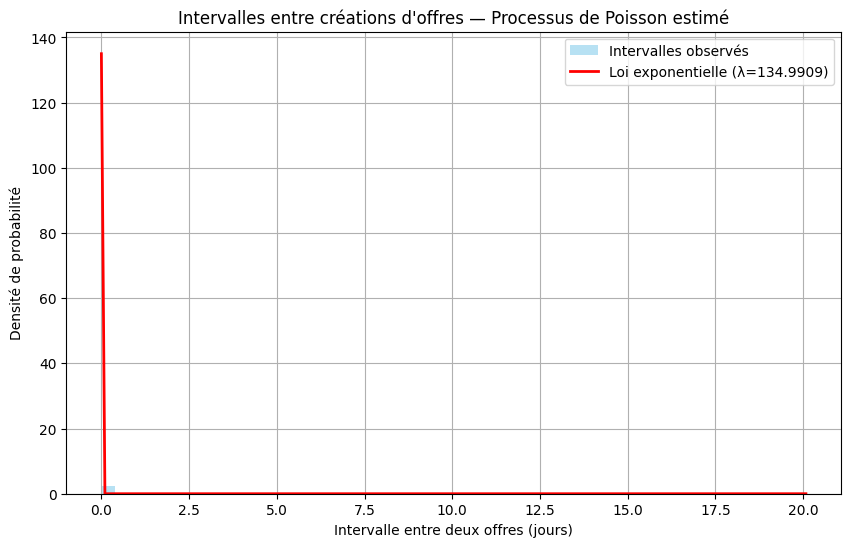

💾 Loi de Poisson sauvegardée dans 'processus_poisson_offres.pkl'


In [4]:
# === 1️⃣ Charger les données (exemple) ===
# Suppose qu'on a déjà un DataFrame `offres` avec une colonne 'off_date_creation'
# offres = pd.read_sql("SELECT off_date_creation FROM dbo.t_offre WHERE off_date_creation >= DATEADD(YEAR, -4, GETDATE())", connexion)

# Conversion en datetime
offres_dates_creation['off_date_creation'] = pd.to_datetime(offres_dates_creation['off_date_creation'])

# Trier par date
offres_dates_creation = offres_dates_creation.sort_values('off_date_creation').reset_index(drop=True)

# === 2️⃣ Calculer les intervalles entre créations successives ===
# En jours :
intervalles = offres_dates_creation['off_date_creation'].diff().dropna().dt.total_seconds() / (3600 * 24)

# === 3️⃣ Estimation du paramètre λ (lambda) du processus de Poisson ===
# Sous un processus de Poisson homogène, Δt ~ Exp(λ)
lambda_estime = 1 / intervalles.mean()

print(f"✅ Taux de création estimé (λ) : {lambda_estime:.6f} offres par jour")

# === 4️⃣ Visualisation : histogramme empirique + densité théorique ===
x = np.linspace(0, intervalles.max(), 200)
plt.figure(figsize=(10,6))
plt.hist(intervalles, bins=50, density=True, alpha=0.6, color='skyblue', label="Intervalles observés")
plt.plot(x, expon.pdf(x, scale=1/lambda_estime), 'r-', lw=2, label=f"Loi exponentielle (λ={lambda_estime:.4f})")
plt.title("Intervalles entre créations d'offres — Processus de Poisson estimé")
plt.xlabel("Intervalle entre deux offres (jours)")
plt.ylabel("Densité de probabilité")
plt.legend()
plt.grid(True)
plt.show()

# === 5️⃣ Sauvegarde du paramètre dans un fichier ===
modele_poisson = {'lambda': lambda_estime}

with open("processus_poisson_offres.pkl", "wb") as f:
    pickle.dump(modele_poisson, f)

print("💾 Loi de Poisson sauvegardée dans 'processus_poisson_offres.pkl'")


📅 Simulation entre 2025-10-23 et 2026-10-23
✅ 49240 offres simulées sur un an


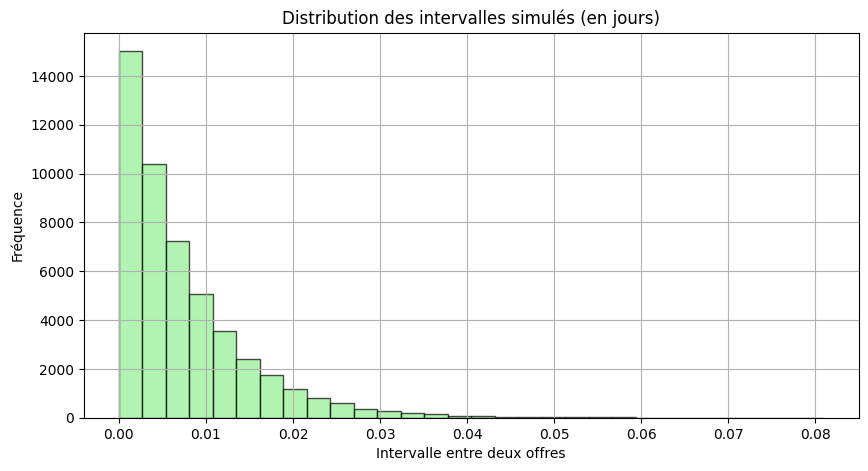

In [ ]:
# # Code à copier / coller dans le notebook final pour simuler les dates de création d'offres

# with open("processus_poisson_offres.pkl", "rb") as f:
#     modele_poisson = pickle.load(f)

# lambda_estime = modele_poisson['lambda']
# print(f"λ rechargé : {lambda_estime:.6f} offres / jour")

# # === 2️⃣ Définir la période de simulation ===
# date_depart = offres_dates_creation['off_date_creation'].max()
# date_fin = date_depart + pd.Timedelta(days=365)

# print(f"📅 Simulation entre {date_depart.date()} et {date_fin.date()}")

# # === 3️⃣ Simulation des inter-arrivées ===
# intervalles_simules = []
# somme = 0

# # Tirages exponentiels jusqu’à dépasser la période de 1 an
# while somme < 365:
#     delta = expon(scale=1/lambda_estime).rvs()  # en jours
#     somme += delta
#     intervalles_simules.append(delta)

# # === 4️⃣ Conversion en dates ===
# dates_simulees = [date_depart + pd.Timedelta(days=sum(intervalles_simules[:i])) for i in range(1, len(intervalles_simules)+1)]
# df_simulees = pd.DataFrame({'date_creation_simulee': dates_simulees})

# print(f"✅ {len(df_simulees)} offres simulées sur un an")

# # === 5️⃣ Visualisation ===
# plt.figure(figsize=(10, 5))
# plt.hist(np.diff([d.timestamp() for d in df_simulees['date_creation_simulee']]) / (3600*24),
#          bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
# plt.title("Distribution des intervalles simulés (en jours)")
# plt.xlabel("Intervalle entre deux offres")
# plt.ylabel("Fréquence")
# plt.grid(True)
# plt.show()